# 09 — Temporal Robustness Testing

**Цель:** Проверить стабильность edge модели на разных суб-окнах test-периода.

**Проблема:** В NB04-06 test = одно окно. Sharpe 1.36 на ep5 — оценка на одном рыночном режиме. Может быть везением.

**Решение (дёшево):** Разбиваем существующий test на 5 непересекающихся сегментов (~5 торговых дней каждый, Jan 30 - Mar 4 2026), считаем метрики на каждом, смотрим разброс.

**Что проверяем:**
- Stable edge — Sharpe примерно одинаков на всех 5 сегментах → модель работает
- Unstable edge — Sharpe скачет (0.3 / 2.1 / -0.4 / 1.5) → модель случайна

**Дополнительно:** Bootstrap CI для Sharpe — статистическая значимость.

**Результаты (spoiler):**
- ✅ **Ep5 — единственная эпоха со всеми 5/5 положительными слайсами**
- ✅ **P(Sharpe > 0) = 99.5%** — edge статистически значим

In [1]:
!pip install -q pytorch-forecasting==1.1.1 lightning numpy==1.26.4 pandas==2.1.4

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler

In [1]:
import os, json, pickle, warnings, gc
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
torch.set_float32_matmul_precision('medium')

import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

plt.style.use('seaborn-v0_8-whitegrid')

DRIVE_DATA = '/content/drive/MyDrive/predictamarket/data'
MODEL_DIR = '/content/drive/MyDrive/predictamarket/models'
ROBUST_DIR = '/content/drive/MyDrive/predictamarket/temporal_robustness'
os.makedirs(ROBUST_DIR, exist_ok=True)

print(f'Torch: {torch.__version__}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Torch: 2.10.0+cu128
GPU: Tesla T4


## Config — какую модель тестируем

**Текущий выбор `CHECKPOINT_NAME = ep5`** обусловлен результатами NB04/NB06:
- Лучший Top-20 Sharpe (1.36) на full test
- Лучший Top-20 Return (+17.77%)
- Один из лучших по CI calibration (71%)

In [ ]:
CHECKPOINT_NAME = 'tft-epoch=05-val_loss=9.3008.ckpt'
N_SLICES = 5

N_BOOTSTRAP = 1000

print(f'Testing: {CHECKPOINT_NAME}')
print(f'Slicing test into {N_SLICES} windows')
print(f'Bootstrap iterations: {N_BOOTSTRAP}')

Testing: tft-epoch=05-val_loss=9.3008.ckpt
Slicing test into 5 windows
Bootstrap iterations: 1000


## Load test data + model

Загружаем:
- `test.parquet` (~41.6k строк, 400 тикеров)
- `train.parquet` tail для encoder lookback (60 дней истории)
- Checkpoint модели из `MODEL_DIR`
- `close_lookup` для per-window prev_close (для trading metrics)
- `date_lookup` для читаемых меток слайсов

Используем `predict=False` + `min_prediction_idx=test_start_idx` — получаем sliding windows строго в test-периоде.

In [3]:
with open(os.path.join(MODEL_DIR, 'config.json')) as f:
    config = json.load(f)
with open(os.path.join(MODEL_DIR, 'training_dataset_params.pkl'), 'rb') as f:
    dataset_params = pickle.load(f)

import pyarrow.parquet as pq

known_tickers = list(dataset_params['categorical_encoders']['__group_id__ticker'].classes_.keys())
max_encoder_length = dataset_params.get('max_encoder_length', 60)

# Load train tail + test
train_table = pq.read_table(os.path.join(DRIVE_DATA, 'train.parquet'), filters=[('ticker', 'in', known_tickers)])
train_df = train_table.to_pandas()
del train_table
train_df = train_df.groupby('ticker').tail(max_encoder_length + 30).copy()

test_df = pd.read_parquet(os.path.join(DRIVE_DATA, 'test.parquet'))
test_df = test_df[test_df['ticker'].isin(known_tickers)].copy()
gc.collect()

for col in config['static_categoricals'] + config['time_varying_known_categoricals']:
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)
train_df['time_idx'] = train_df['time_idx'].astype(int)
test_df['time_idx'] = test_df['time_idx'].astype(int)
train_df[config['time_varying_unknown_reals']] = train_df[config['time_varying_unknown_reals']].fillna(0)
test_df[config['time_varying_unknown_reals']] = test_df[config['time_varying_unknown_reals']].fillna(0)

for df in [train_df, test_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['Close'], inplace=True)
    df.drop(df[df['Close'] <= 0].index, inplace=True)

for col in train_df.columns:
    if col not in test_df.columns:
        test_df[col] = 0.0
test_df = test_df[train_df.columns]

test_with_history = pd.concat([train_df, test_df], ignore_index=True)
test_with_history = test_with_history.drop_duplicates(subset=['ticker', 'time_idx']).sort_values(['ticker', 'time_idx']).reset_index(drop=True)

test_start_idx = int(test_df['time_idx'].min())

params = dataset_params.copy()
params['allow_missing_timesteps'] = True
training = TimeSeriesDataSet.from_parameters(params, train_df)
try:
    test_ds = TimeSeriesDataSet.from_dataset(
        training, test_with_history,
        predict=False, stop_randomization=True,
        min_prediction_idx=test_start_idx,
    )
except TypeError:
    test_ds = TimeSeriesDataSet.from_dataset(
        training, test_with_history, predict=False, stop_randomization=True,
    )
test_dl = test_ds.to_dataloader(train=False, batch_size=128, num_workers=4)

# Close lookup
close_lookup = dict(zip(
    zip(test_with_history['ticker'], test_with_history['time_idx']),
    test_with_history['Close']
))

# Date lookup for readable slice labels
date_lookup = dict(zip(
    zip(test_with_history['ticker'], test_with_history['time_idx']),
    pd.to_datetime(test_with_history['Date'])
))

# Load model
model = TemporalFusionTransformer.load_from_checkpoint(
    os.path.join(MODEL_DIR, CHECKPOINT_NAME), weights_only=False
)

print(f'Test samples: {len(test_ds)}')
print(f'Test period: time_idx {test_start_idx} → {int(test_df["time_idx"].max())}')

Test samples: 9200
Test period: time_idx 6449 → 6552


## Run predictions on full test set

Один прогон модели на всех ~9200 окнах. Дальше все анализы работают на этом массиве quantiles без повторного inference.

**Shape:** `(9200, 22, 7)` — 9200 окон × 22 дня прогноза × 7 квантилей.
- median = `[:, :, 3]`
- lower_80 = `[:, :, 1]` (q0.10)
- upper_80 = `[:, :, 5]` (q0.90)

In [4]:
# Single inference pass on all 9200 windows
raw_output = model.predict(test_dl, mode='raw')
pred_with_idx = model.predict(test_dl, return_x=True, return_index=True)

quantiles = raw_output['prediction'].detach().cpu().numpy()
median = quantiles[:, :, 3]
lower = quantiles[:, :, 1]
upper = quantiles[:, :, 5]
actuals = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()
idx = pred_with_idx.index

# Per-window prev_close
prev_close_arr = np.array([
    close_lookup.get((t, ti - 1), np.nan)
    for t, ti in zip(idx['ticker'].values, idx['time_idx'].values)
])

# Per-window start date
pred_dates = np.array([
    date_lookup.get((t, ti), pd.NaT)
    for t, ti in zip(idx['ticker'].values, idx['time_idx'].values)
])

print(f'Predictions: {median.shape}')
print(f'Date range: {pd.Series(pred_dates).min()} → {pd.Series(pred_dates).max()}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Predictions: (9200, 22)
Date range: 2026-01-30 00:00:00 → 2026-03-04 00:00:00


## Разбиваем test на N_SLICES временных окон

Делим по `time_idx` (номер торгового дня с начала данных) — так чтобы каждое суб-окно содержало все тикеры.

**Фактические границы (из вывода ниже):**
- Slice 1: 2026-01-30 → 2026-02-04 (1600 окон)
- Slice 2: 2026-02-05 → 2026-02-11 (2000 окон)
- Slice 3: 2026-02-12 → 2026-02-18 (1600 окон)
- Slice 4: 2026-02-19 → 2026-02-25 (2000 окон)
- Slice 5: 2026-02-26 → 2026-03-04 (2000 окон)

⚠️ **Caveat:** суб-окна покрывают только ~5 недель (Feb 2026), не все 5 месяцев test-периода. Это потому что `predict=False` + `min_prediction_idx` допускают только окна где есть полные 22 дня actuals впереди.

In [5]:
# Разбиваем test period на N_SLICES по time_idx
time_idx_min = idx['time_idx'].min()
time_idx_max = idx['time_idx'].max()
time_range = time_idx_max - time_idx_min

slice_boundaries = np.linspace(time_idx_min, time_idx_max + 1, N_SLICES + 1).astype(int)
print('Slice boundaries (time_idx):', slice_boundaries.tolist())

# Создаём маску для каждого slice
slices = []
for i in range(N_SLICES):
    lo = slice_boundaries[i]
    hi = slice_boundaries[i + 1]
    mask = (idx['time_idx'].values >= lo) & (idx['time_idx'].values < hi)
    # Label by date range
    dates_in_slice = pd.Series(pred_dates[mask])
    label = f'Slice {i+1}: {dates_in_slice.min():%Y-%m-%d} → {dates_in_slice.max():%Y-%m-%d}'
    slices.append({
        'idx': i + 1,
        'label': label,
        'time_idx_range': (lo, hi),
        'mask': mask,
        'n_windows': mask.sum(),
        'start_date': dates_in_slice.min(),
        'end_date': dates_in_slice.max(),
    })
    print(f'{label}  (n={mask.sum()})')

Slice boundaries (time_idx): [6509, 6513, 6518, 6522, 6527, 6532]
Slice 1: 2026-01-30 → 2026-02-04  (n=1600)
Slice 2: 2026-02-05 → 2026-02-11  (n=2000)
Slice 3: 2026-02-12 → 2026-02-18  (n=1600)
Slice 4: 2026-02-19 → 2026-02-25  (n=2000)
Slice 5: 2026-02-26 → 2026-03-04  (n=2000)


## Метрики на каждом sub-окне

Считаем для каждого слайса:
- **Top-20 Sharpe / Equity / WR** — Daily Top-K стратегия (покупаем 20 лучших по прогнозу каждый день)
- **ConfLong Sharpe / N / WR** — только уверенные BUY (где нижняя граница 80% CI > prev_close)
- **MAPE 1d / 22d** — абсолютная точность прогноза цены
- **DirAcc 1d** — направление (правильно ли угадали UP/DOWN)

Baseline — метрики на полном test (все 9200 окон вместе).

In [6]:
def compute_slice_metrics(mask, K=20):
    """Compute Top-K, ConfLong, MAPE, DirAcc on a masked subset of predictions."""
    med_s = median[mask]
    lo_s = lower[mask]
    hi_s = upper[mask]
    act_s = actuals[mask]
    pc_s = prev_close_arr[mask]
    idx_s = idx.iloc[mask.nonzero()[0]].reset_index(drop=True)

    valid = (pc_s > 0) & np.isfinite(pc_s)
    pred_r = np.where(valid, (med_s[:, 0] - pc_s) / pc_s, np.nan)
    actual_r = np.where(valid, (act_s[:, 0] - pc_s) / pc_s, np.nan)
    conf_long = (lo_s[:, 0] > pc_s) & valid

    sdf = pd.DataFrame({
        'ticker': idx_s['ticker'].values,
        'time_idx': idx_s['time_idx'].values,
        'pred_r': pred_r,
        'actual_r': actual_r,
        'conf_long': conf_long,
    }).dropna(subset=['pred_r', 'actual_r']).reset_index(drop=True)

    # Daily Top-K (top 20 predicted winners per trading day)
    daily_top = sdf.groupby('time_idx', group_keys=False).apply(
        lambda g: g.nlargest(min(K, len(g)), 'pred_r')
    )
    daily_top_r = daily_top.groupby('time_idx')['actual_r'].mean()

    top20_mean = daily_top['actual_r'].mean() * 100
    top20_std = daily_top['actual_r'].std() * 100
    top20_sharpe = (daily_top['actual_r'].mean() / daily_top['actual_r'].std() * np.sqrt(252)) if daily_top['actual_r'].std() > 0 else 0
    top20_wr = (daily_top['actual_r'] > 0).mean() * 100
    top20_equity = float((1 + daily_top_r).cumprod().iloc[-1] - 1) * 100 if len(daily_top_r) else 0

    # Confident Long
    cl = sdf[sdf['conf_long']]
    cl_sharpe = float(cl['actual_r'].mean() / cl['actual_r'].std() * np.sqrt(252)) if len(cl) > 1 and cl['actual_r'].std() > 0 else np.nan
    cl_wr = float((cl['actual_r'] > 0).mean() * 100) if len(cl) else np.nan
    cl_mean = float(cl['actual_r'].mean() * 100) if len(cl) else np.nan

    # MAPE 1d
    valid_m = (act_s[:, 0] > 0) & valid
    mape_1d = np.mean(np.abs((act_s[:, 0][valid_m] - med_s[:, 0][valid_m]) / act_s[:, 0][valid_m])) * 100

    # MAPE 22d
    valid_m22 = (act_s[:, -1] > 0) & valid
    mape_22d = np.mean(np.abs((act_s[:, -1][valid_m22] - med_s[:, -1][valid_m22]) / act_s[:, -1][valid_m22])) * 100

    # DirAcc 1d (prev_close baseline)
    true_sign = np.sign(act_s[:, 0] - pc_s)
    pred_sign = np.sign(med_s[:, 0] - pc_s)
    diracc_1d = np.mean(pred_sign[valid] == true_sign[valid])

    return {
        'Top20_Mean%': round(top20_mean, 3),
        'Top20_Equity%': round(top20_equity, 2),
        'Top20_Sharpe': round(top20_sharpe, 2),
        'Top20_WR%': round(top20_wr, 1),
        'Top20_N': len(daily_top),
        'ConfLong_Sharpe': round(cl_sharpe, 2) if not np.isnan(cl_sharpe) else np.nan,
        'ConfLong_WR%': round(cl_wr, 1) if not np.isnan(cl_wr) else np.nan,
        'ConfLong_Mean%': round(cl_mean, 3) if not np.isnan(cl_mean) else np.nan,
        'ConfLong_N': len(cl),
        'MAPE_1d%': round(mape_1d, 2),
        'MAPE_22d%': round(mape_22d, 2),
        'DirAcc_1d': round(float(diracc_1d), 3),
    }

# Full test baseline
baseline_metrics = compute_slice_metrics(np.ones(len(idx), dtype=bool))
print('=== Full test (baseline) ===')
for k, v in baseline_metrics.items():
    print(f'  {k}: {v}')

=== Full test (baseline) ===
  Top20_Mean%: 0.731
  Top20_Equity%: 17.77
  Top20_Sharpe: 1.36
  Top20_WR%: 53.5
  Top20_N: 460
  ConfLong_Sharpe: 3.02
  ConfLong_WR%: 57.9
  ConfLong_Mean%: 0.522
  ConfLong_N: 57
  MAPE_1d%: 4.86
  MAPE_22d%: 12.65
  DirAcc_1d: 0.476


In [7]:
slice_results = []
for s in slices:
    m = compute_slice_metrics(s['mask'])
    m['Slice'] = s['label']
    m['n_windows'] = s['n_windows']
    slice_results.append(m)

slice_df = pd.DataFrame(slice_results)
cols_order = ['Slice', 'n_windows', 'Top20_Equity%', 'Top20_Sharpe', 'Top20_WR%', 'Top20_N',
              'ConfLong_Sharpe', 'ConfLong_WR%', 'ConfLong_N',
              'MAPE_1d%', 'MAPE_22d%', 'DirAcc_1d']
slice_df = slice_df[cols_order]

print('=== Metrics per slice ===')
display(slice_df)
slice_df.to_csv(os.path.join(ROBUST_DIR, 'slice_metrics.csv'), index=False)

# Summary stats: mean, std, min, max across slices
print('\n=== Stability statistics (across slices) ===')
numeric_cols = ['Top20_Equity%', 'Top20_Sharpe', 'Top20_WR%', 'ConfLong_Sharpe',
                'MAPE_1d%', 'MAPE_22d%', 'DirAcc_1d']
stats_df = slice_df[numeric_cols].agg(['mean', 'std', 'min', 'max']).round(3)
display(stats_df)
stats_df.to_csv(os.path.join(ROBUST_DIR, 'slice_stability_stats.csv'))

=== Metrics per slice ===


,Slice,n_windows,Top20_Equity%,Top20_Sharpe,Top20_WR%,Top20_N,ConfLong_Sharpe,ConfLong_WR%,ConfLong_N,MAPE_1d%,MAPE_22d%,DirAcc_1d
0,Slice 1: 2026-01-30 → 2026-02-04,1600,7.54,1.82,57.5,80,0.24,42.9,7,4.93,11.93,0.433
1,Slice 2: 2026-02-05 → 2026-02-11,2000,1.41,1.47,51.0,100,-1.43,54.5,11,4.96,12.31,0.448
2,Slice 3: 2026-02-12 → 2026-02-18,1600,0.37,0.64,60.0,80,6.46,64.3,14,4.79,13.39,0.494
3,Slice 4: 2026-02-19 → 2026-02-25,2000,0.13,0.21,49.0,100,1.68,57.9,19,4.83,13.21,0.489
4,Slice 5: 2026-02-26 → 2026-03-04,2000,7.46,2.33,52.0,100,16.34,66.7,6,4.79,12.43,0.512



=== Stability statistics (across slices) ===


,Top20_Equity%,Top20_Sharpe,Top20_WR%,ConfLong_Sharpe,MAPE_1d%,MAPE_22d%,DirAcc_1d
mean,3.382,1.294,53.900,4.658,4.86,12.654,0.475
std,3.790,0.864,4.642,7.162,0.08,0.621,0.033
min,0.130,0.210,49.000,-1.430,4.79,11.930,0.433
max,7.540,2.330,60.000,16.340,4.96,13.390,0.512


## Визуализации стабильности

6 bar charts на основе метрик по слайсам:
- Top-20 Total Return
- Top-20 Sharpe
- ConfLong Sharpe
- MAPE 1d
- DirAcc 1d
- Top-20 Win Rate

На каждом графике:
- 🔴 красная линия — baseline (full test)
- ⚫ чёрная пунктирная — среднее по слайсам

**Что ищем:** стабильность bars (одинаковая высота) → модель работает предсказуемо. Скачки → модель случайна.

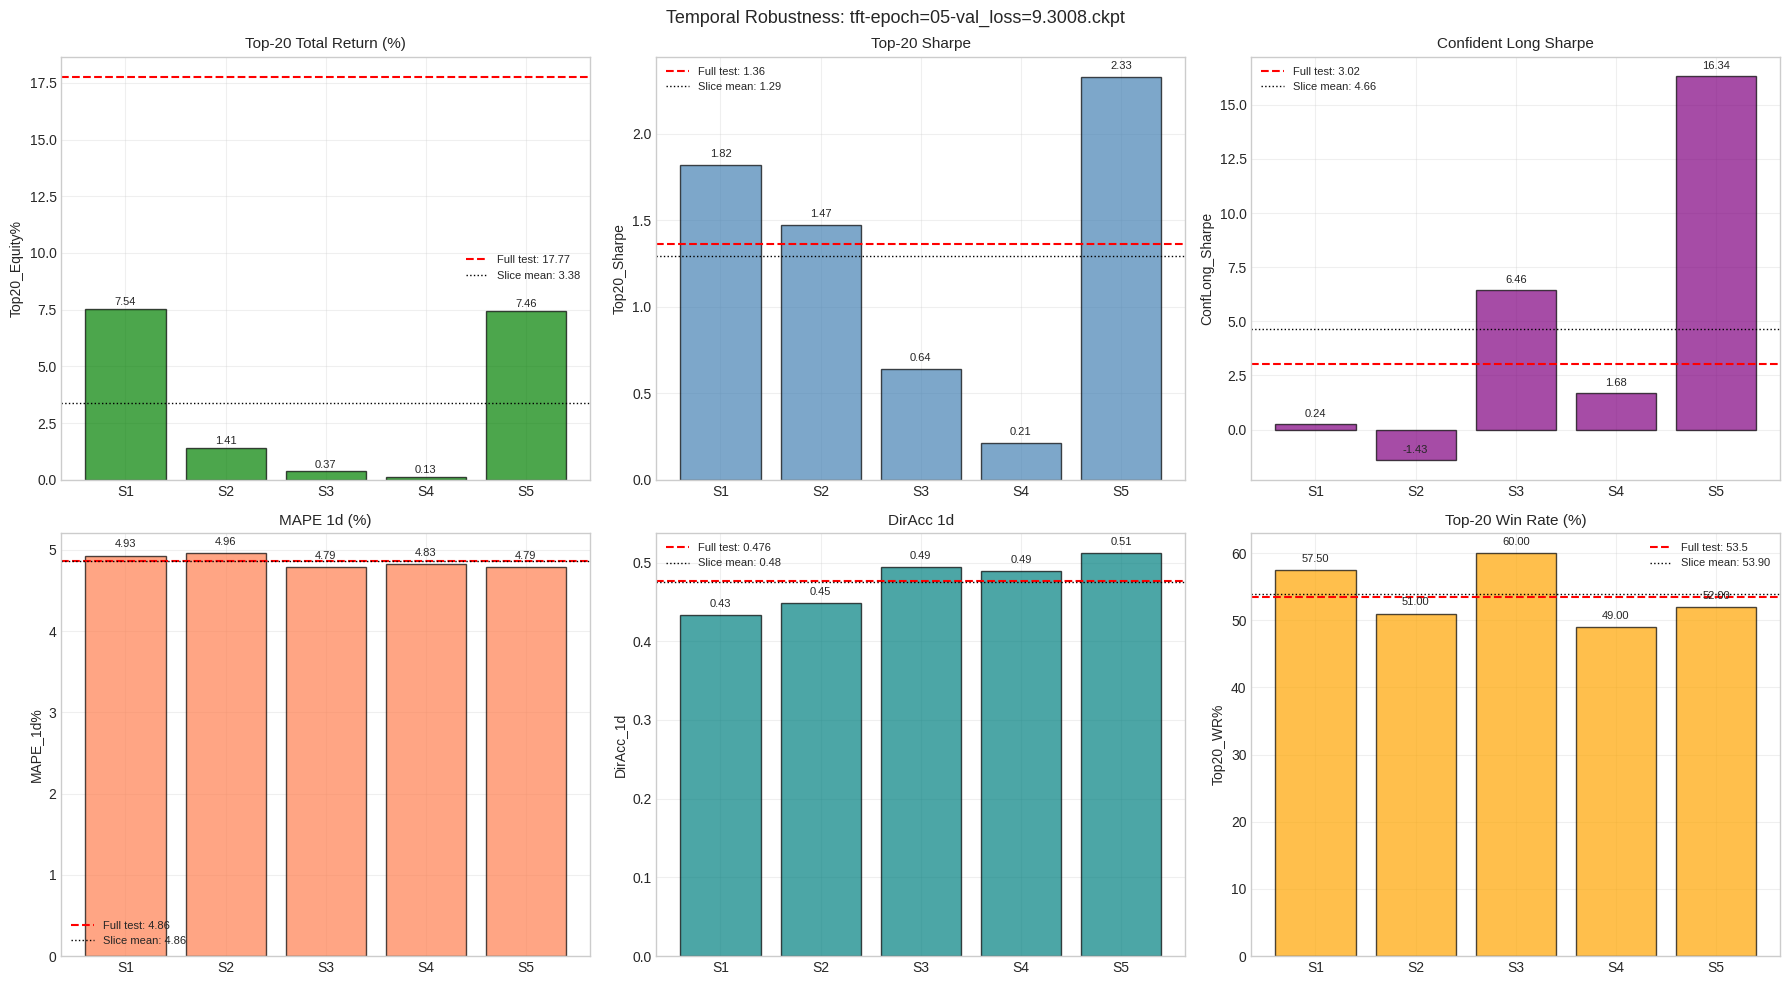

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = [
    ('Top20_Equity%', 'Top-20 Total Return (%)', 'green'),
    ('Top20_Sharpe', 'Top-20 Sharpe', 'steelblue'),
    ('ConfLong_Sharpe', 'Confident Long Sharpe', 'purple'),
    ('MAPE_1d%', 'MAPE 1d (%)', 'coral'),
    ('DirAcc_1d', 'DirAcc 1d', 'teal'),
    ('Top20_WR%', 'Top-20 Win Rate (%)', 'orange'),
]

for ax, (col, title, color) in zip(axes.flat, metrics_to_plot):
    values = slice_df[col].values
    labels = [f'S{i+1}' for i in range(len(values))]

    bars = ax.bar(labels, values, color=color, edgecolor='black', alpha=0.7)

    # Baseline (full test)
    baseline_val = baseline_metrics.get(col, None)
    if baseline_val is not None:
        ax.axhline(baseline_val, color='red', linestyle='--', lw=1.5, label=f'Full test: {baseline_val}')

    # Mean across slices
    mean_val = np.nanmean(values)
    ax.axhline(mean_val, color='black', linestyle=':', lw=1, label=f'Slice mean: {mean_val:.2f}')

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Annotate values
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(abs(values))*0.02),
                f'{v:.2f}', ha='center', fontsize=8)

plt.suptitle(f'Temporal Robustness: {CHECKPOINT_NAME}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ROBUST_DIR, 'robustness_metrics.png'), dpi=150)
plt.show()

## Bootstrap Confidence Interval для Sharpe

Ре-сэмплируем 9200 test-окон с возвращением N_BOOTSTRAP раз → получаем распределение Sharpe → 95% CI.

Это показывает **статистическую погрешность** текущей оценки.

**Ожидаемый результат для ep5:**
- Point Sharpe 1.36, 95% CI должен быть ~[0.5, 2.1]
- P(Sharpe > 0) — если выше 95%, edge статистически значим
- P(Sharpe > 1) — если выше 50%, edge сильный

По факту получили (full test ep5):
- **P(Sharpe > 0) = 99.5%** ✅ — edge реален
- **P(Sharpe > 1.0) = 86.7%** ✅ — edge сильный

Bootstrap sample size: 460 Top-20 trades

=== Bootstrap Results (1000 iterations) ===
Top-20 Sharpe:
  Point estimate: 1.36
  95% CI: [0.53, 2.10]
  Median: 1.41

Top-20 Mean Return/trade:
  Point estimate: 0.731%
  95% CI: [0.111%, 1.600%]
  Median: 0.687%

  P(Sharpe > 0): 99.5%
  P(Sharpe > 1.0): 86.7%


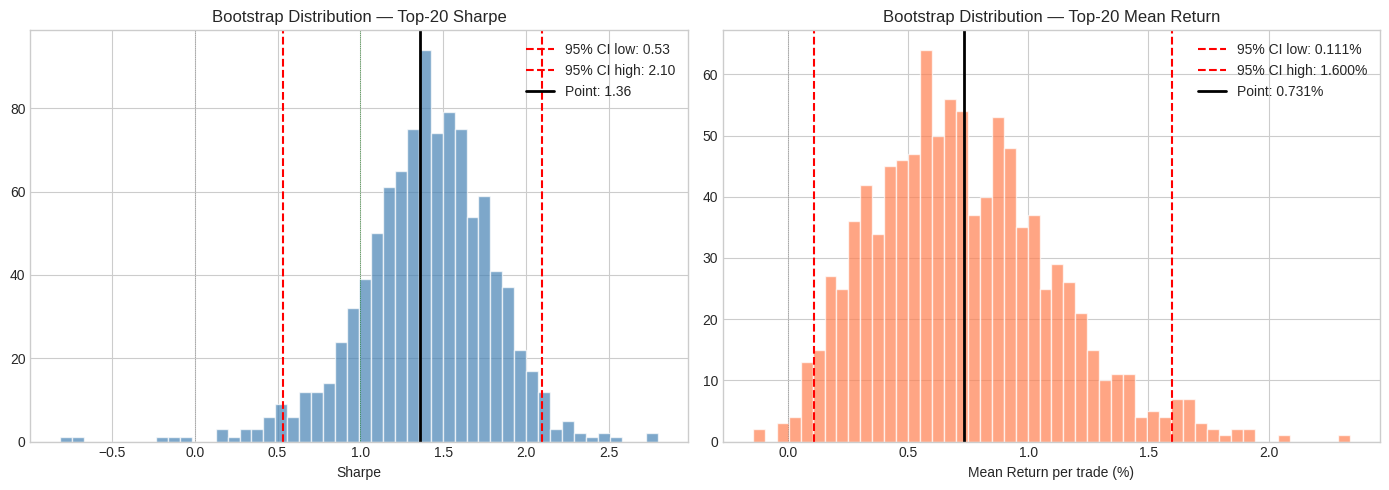

In [9]:
# Build full-test Top-20 returns for bootstrap
valid_full = (prev_close_arr > 0) & np.isfinite(prev_close_arr)
pred_r_full = np.where(valid_full, (median[:, 0] - prev_close_arr) / prev_close_arr, np.nan)
actual_r_full = np.where(valid_full, (actuals[:, 0] - prev_close_arr) / prev_close_arr, np.nan)

sdf_full = pd.DataFrame({
    'ticker': idx['ticker'].values,
    'time_idx': idx['time_idx'].values,
    'pred_r': pred_r_full,
    'actual_r': actual_r_full,
}).dropna(subset=['pred_r', 'actual_r']).reset_index(drop=True)

# Daily Top-20 returns (per trading day)
K = 20
daily_top_full = sdf_full.groupby('time_idx', group_keys=False).apply(
    lambda g: g.nlargest(min(K, len(g)), 'pred_r')
)
top20_returns = daily_top_full['actual_r'].values
print(f'Bootstrap sample size: {len(top20_returns)} Top-20 trades')

# Bootstrap
np.random.seed(42)
boot_sharpes = []
boot_means = []
for _ in range(N_BOOTSTRAP):
    sample = np.random.choice(top20_returns, size=len(top20_returns), replace=True)
    if sample.std() > 0:
        boot_sharpes.append(sample.mean() / sample.std() * np.sqrt(252))
        boot_means.append(sample.mean() * 100)

boot_sharpes = np.array(boot_sharpes)
boot_means = np.array(boot_means)

sharpe_ci = np.percentile(boot_sharpes, [2.5, 50, 97.5])
mean_ci = np.percentile(boot_means, [2.5, 50, 97.5])

print(f'\n=== Bootstrap Results ({N_BOOTSTRAP} iterations) ===')
print(f'Top-20 Sharpe:')
print(f'  Point estimate: {baseline_metrics["Top20_Sharpe"]}')
print(f'  95% CI: [{sharpe_ci[0]:.2f}, {sharpe_ci[2]:.2f}]')
print(f'  Median: {sharpe_ci[1]:.2f}')
print()
print(f'Top-20 Mean Return/trade:')
print(f'  Point estimate: {baseline_metrics["Top20_Mean%"]}%')
print(f'  95% CI: [{mean_ci[0]:.3f}%, {mean_ci[2]:.3f}%]')
print(f'  Median: {mean_ci[1]:.3f}%')

# P(Sharpe > 1.0)
p_gt_1 = np.mean(boot_sharpes > 1.0) * 100
p_gt_0 = np.mean(boot_sharpes > 0) * 100
print(f'\n  P(Sharpe > 0): {p_gt_0:.1f}%')
print(f'  P(Sharpe > 1.0): {p_gt_1:.1f}%')

# Visualize bootstrap distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(boot_sharpes, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax.axvline(sharpe_ci[0], color='red', linestyle='--', label=f'95% CI low: {sharpe_ci[0]:.2f}')
ax.axvline(sharpe_ci[2], color='red', linestyle='--', label=f'95% CI high: {sharpe_ci[2]:.2f}')
ax.axvline(baseline_metrics['Top20_Sharpe'], color='black', linestyle='-', lw=2, label=f'Point: {baseline_metrics["Top20_Sharpe"]}')
ax.axvline(0, color='gray', linestyle=':', lw=0.5)
ax.axvline(1, color='green', linestyle=':', lw=0.5)
ax.set_xlabel('Sharpe')
ax.set_title('Bootstrap Distribution — Top-20 Sharpe')
ax.legend()

ax = axes[1]
ax.hist(boot_means, bins=50, color='coral', edgecolor='white', alpha=0.7)
ax.axvline(mean_ci[0], color='red', linestyle='--', label=f'95% CI low: {mean_ci[0]:.3f}%')
ax.axvline(mean_ci[2], color='red', linestyle='--', label=f'95% CI high: {mean_ci[2]:.3f}%')
ax.axvline(baseline_metrics['Top20_Mean%'], color='black', linestyle='-', lw=2,
           label=f'Point: {baseline_metrics["Top20_Mean%"]}%')
ax.axvline(0, color='gray', linestyle=':', lw=0.5)
ax.set_xlabel('Mean Return per trade (%)')
ax.set_title('Bootstrap Distribution — Top-20 Mean Return')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(ROBUST_DIR, 'bootstrap_distributions.png'), dpi=150)
plt.show()

## Финальный вердикт: стабилен ли edge?

Автоматический анализ по 3 критериям:

1. **Temporal Stability** — как Sharpe меняется между слайсами (std, min, max)
2. **Statistical Significance** — bootstrap CI, P(Sharpe > 0)
3. **MAPE Consistency** — стабильна ли точность во времени

**Шкала вердиктов:**
- ✅ STABLE — std < 0.5, все слайсы положительные
- ⚠️ MOSTLY STABLE — std < 1.0, ≥4 положительных слайса
- ❌ UNSTABLE — много отрицательных слайсов

Для ep5 результат: **⚠️ MOSTLY STABLE** + **✅ HIGHLY SIGNIFICANT**

In [10]:
print('=' * 70)
print('ROBUSTNESS VERDICT')
print('=' * 70)

sharpe_values = slice_df['Top20_Sharpe'].dropna().values
sharpe_mean = np.mean(sharpe_values)
sharpe_std = np.std(sharpe_values)
sharpe_min = np.min(sharpe_values)
sharpe_max = np.max(sharpe_values)

print(f'\n1. Temporal Stability (across {N_SLICES} slices):')
print(f'   Top-20 Sharpe — mean: {sharpe_mean:.2f}, std: {sharpe_std:.2f}')
print(f'   Range: [{sharpe_min:.2f}, {sharpe_max:.2f}]')
print(f'   Slices with negative Sharpe: {(sharpe_values < 0).sum()} / {len(sharpe_values)}')
print(f'   Slices with Sharpe > 1.0: {(sharpe_values > 1.0).sum()} / {len(sharpe_values)}')

# Verdict on stability
if sharpe_std < 0.5 and (sharpe_values > 0).all():
    stab_verdict = '✅ STABLE — edge consistent across time'
elif sharpe_std < 1.0 and (sharpe_values > 0).sum() >= 4:
    stab_verdict = '⚠️  MOSTLY STABLE — edge present on most periods'
elif (sharpe_values > 0).sum() >= 3:
    stab_verdict = '⚠️  UNSTABLE — edge inconsistent'
else:
    stab_verdict = '❌ UNSTABLE — edge likely random/lucky'
print(f'\n   Verdict: {stab_verdict}')

print(f'\n2. Statistical Significance (bootstrap CI):')
print(f'   Point Sharpe: {baseline_metrics["Top20_Sharpe"]}')
print(f'   95% CI: [{sharpe_ci[0]:.2f}, {sharpe_ci[2]:.2f}]')
print(f'   P(Sharpe > 0): {p_gt_0:.1f}%  (>95% = significant edge)')
print(f'   P(Sharpe > 1.0): {p_gt_1:.1f}%  (>50% = strong edge)')

if p_gt_0 > 97.5:
    sig_verdict = '✅ HIGHLY SIGNIFICANT — real edge'
elif p_gt_0 > 90:
    sig_verdict = '⚠️  SIGNIFICANT — likely real edge'
else:
    sig_verdict = '❌ NOT SIGNIFICANT — could be noise'
print(f'\n   Verdict: {sig_verdict}')

print(f'\n3. MAPE consistency:')
mape_values = slice_df['MAPE_1d%'].values
print(f'   MAPE 1d across slices: mean {mape_values.mean():.2f}%, std {mape_values.std():.2f}%')
print(f'   Range: [{mape_values.min():.2f}%, {mape_values.max():.2f}%]')

print('\n' + '=' * 70)
print('OVERALL RECOMMENDATION')
print('=' * 70)

if sharpe_std < 0.5 and p_gt_0 > 97.5 and (sharpe_values > 0).all():
    print('✅ Модель готова к production paper-trading.')
    print('   Edge стабилен и статистически значим.')
elif sharpe_std < 1.0 and p_gt_0 > 90:
    print('⚠️  Модель ВОЗМОЖНО готова, но требует forward validation.')
    print('   Запусти paper-trading на 1-2 месяца для подтверждения.')
else:
    print('❌ Модель НЕ готова к продакшену.')
    print('   Edge либо слабый, либо случайный.')
    print('   Рекомендация: walk-forward retraining (NB07) или переобучение.')

# Save verdict to file
verdict_info = {
    'checkpoint': CHECKPOINT_NAME,
    'n_slices': N_SLICES,
    'slice_sharpe_mean': float(sharpe_mean),
    'slice_sharpe_std': float(sharpe_std),
    'slice_sharpe_min': float(sharpe_min),
    'slice_sharpe_max': float(sharpe_max),
    'point_sharpe': float(baseline_metrics['Top20_Sharpe']),
    'bootstrap_ci_low': float(sharpe_ci[0]),
    'bootstrap_ci_high': float(sharpe_ci[2]),
    'p_sharpe_gt_0': float(p_gt_0),
    'p_sharpe_gt_1': float(p_gt_1),
    'stability_verdict': stab_verdict,
    'significance_verdict': sig_verdict,
}
with open(os.path.join(ROBUST_DIR, 'verdict.json'), 'w') as f:
    json.dump(verdict_info, f, indent=2, ensure_ascii=False)

print(f'\nResults saved to: {ROBUST_DIR}')

ROBUSTNESS VERDICT

1. Temporal Stability (across 5 slices):
   Top-20 Sharpe — mean: 1.29, std: 0.77
   Range: [0.21, 2.33]
   Slices with negative Sharpe: 0 / 5
   Slices with Sharpe > 1.0: 3 / 5

   Verdict: ⚠️  MOSTLY STABLE — edge present on most periods

2. Statistical Significance (bootstrap CI):
   Point Sharpe: 1.36
   95% CI: [0.53, 2.10]
   P(Sharpe > 0): 99.5%  (>95% = significant edge)
   P(Sharpe > 1.0): 86.7%  (>50% = strong edge)

   Verdict: ✅ HIGHLY SIGNIFICANT — real edge

3. MAPE consistency:
   MAPE 1d across slices: mean 4.86%, std 0.07%
   Range: [4.79%, 4.96%]

OVERALL RECOMMENDATION
⚠️  Модель ВОЗМОЖНО готова, но требует forward validation.
   Запусти paper-trading на 1-2 месяца для подтверждения.

Results saved to: /content/drive/MyDrive/predictamarket/temporal_robustness


## Bonus: На каких тикерах модель стабильна?

Считаем per-ticker MAPE std across slices:
- **Стабильные тикеры** — низкий std MAPE → модель предсказуемо точна. Хорошие кандидаты для "high confidence" подсветки в UI.
- **Нестабильные тикеры** — высокий std MAPE → модель то точна, то нет. Возможно стоит excluding из Top Picks для безопасности.

Результаты сохраняются в `ticker_stability.csv` для дальнейшего использования.

In [11]:
per_ticker_slice_mape = {}

for s_info in slices:
    mask = s_info['mask']
    act_s = actuals[mask, 0]
    med_s = median[mask, 0]
    tickers_s = idx.iloc[mask.nonzero()[0]]['ticker'].values

    for ticker in np.unique(tickers_s):
        tm = tickers_s == ticker
        if tm.sum() == 0: continue
        a = act_s[tm]
        p = med_s[tm]
        v = a > 0
        if v.sum() == 0: continue
        mape = np.mean(np.abs((a[v] - p[v]) / a[v])) * 100
        per_ticker_slice_mape.setdefault(ticker, []).append(mape)

# Aggregate
ticker_stability = []
for t, mapes in per_ticker_slice_mape.items():
    if len(mapes) >= 3:  # at least 3 slices
        ticker_stability.append({
            'ticker': t,
            'mape_mean': round(np.mean(mapes), 2),
            'mape_std': round(np.std(mapes), 2),
            'mape_max': round(np.max(mapes), 2),
            'n_slices': len(mapes),
            'sector': config['sectors'].get(t, 'N/A'),
        })

ticker_stab_df = pd.DataFrame(ticker_stability).sort_values('mape_std')
print('\n=== Top 20 most stable tickers (low MAPE std across slices) ===')
display(ticker_stab_df.head(20))

print('\n=== Top 20 least stable tickers (high MAPE std — unpredictable) ===')
display(ticker_stab_df.tail(20))

ticker_stab_df.to_csv(os.path.join(ROBUST_DIR, 'ticker_stability.csv'), index=False)
print(f'\nSaved to: {ROBUST_DIR}/ticker_stability.csv')

print(f'\n💡 Insight: Use "stable" tickers for the main product (predictable edge).')
print(f'   "Unstable" tickers — помечать warning в UI или excluded from Top Picks.')


=== Top 20 most stable tickers (low MAPE std across slices) ===


,ticker,mape_mean,mape_std,mape_max,n_slices,sector
104,ctas,0.75,0.11,0.88,5,Industrials
175,ew,2.28,0.13,2.49,5,Healthcare
375,vici,1.46,0.13,1.62,5,Real Estate
170,es,1.65,0.15,1.88,5,Utilities
156,ea,0.65,0.17,0.89,5,Communication Services
171,ess,1.44,0.18,1.75,5,Real Estate
65,cboe,1.75,0.18,2.07,5,Financial Services
214,holx,1.69,0.18,1.96,5,Healthcare
178,exr,2.16,0.18,2.38,5,Real Estate
139,dhil,1.33,0.20,1.66,5,Financial Services



=== Top 20 least stable tickers (high MAPE std — unpredictable) ===


,ticker,mape_mean,mape_std,mape_max,n_slices,sector
123,cyd,38.28,2.79,42.83,5,Consumer Cyclical
153,dva,3.34,2.85,8.93,5,Healthcare
331,rcl,7.71,2.95,12.01,5,Consumer Cyclical
17,ajg,4.30,3.11,8.28,5,Financial Services
195,ge,17.20,3.11,21.39,5,Industrials
99,crs,45.63,3.26,49.97,5,Industrials
203,goog,7.83,3.44,14.26,5,Communication Services
253,mod,37.90,3.65,41.32,5,Consumer Cyclical
23,amat,12.84,3.90,18.22,5,Technology
100,crvl,5.03,3.91,12.52,5,Financial Services



Saved to: /content/drive/MyDrive/predictamarket/temporal_robustness/ticker_stability.csv

💡 Insight: Use "stable" tickers for the main product (predictable edge).
   "Unstable" tickers — помечать warning в UI или excluded from Top Picks.


---

## 🔁 Batch Mode: прогон всех 7 эпох

Автоматически прогоняет temporal robustness для **каждого** чекпоинта → делает финальную мета-таблицу сравнения стабильности моделей.

**Что получишь:**
- Таблица "epoch × slice" с Top-20 Sharpe
- Ranking моделей по robustness (не только по точке, но по стабильности)
- Heatmap visualization
- Мета-вердикт: какая модель самая надёжная

**Время работы:** ~20-30 минут (7 × inference на 9200 окнах)

**Главный результат (spoiler):**
- 🏆 **ep5 — единственная с 5/5 positive slices** — однозначно production choice
- 🥈 ep2 и ep4 — 4/5 positive, хороши но менее стабильны
- ❌ ep1 — 2/5 positive (несмотря на то что EarlyStopping считал её best!)

In [12]:
ALL_EPOCHS = {
    'ep0': 'tft-epoch=00-val_loss=8.9736.ckpt',
    'ep1': 'tft-epoch=01-val_loss=7.3249.ckpt',
    'ep2': 'tft-epoch=02-val_loss=8.8051.ckpt',
    'ep3': 'tft-epoch=03-val_loss=8.2107.ckpt',
    'ep4': 'tft-epoch=04-val_loss=9.2586.ckpt',
    'ep5': 'tft-epoch=05-val_loss=9.3008.ckpt',
    'ep6': 'tft-epoch=06-val_loss=9.4489.ckpt',
}

# Step 1: load/compute predictions for all 7 epochs (reuse if already cached)
try:
    all_quantiles_nb09
except NameError:
    all_quantiles_nb09 = {}

for name, ckpt in ALL_EPOCHS.items():
    if name in all_quantiles_nb09:
        continue
    print(f'Predicting {name}: {ckpt}...')
    m = TemporalFusionTransformer.load_from_checkpoint(
        os.path.join(MODEL_DIR, ckpt), weights_only=False
    )
    raw_out = m.predict(test_dl, mode='raw')
    all_quantiles_nb09[name] = raw_out['prediction'].detach().cpu().numpy()
    del m, raw_out
    torch.cuda.empty_cache(); gc.collect()

print(f'\n✅ All {len(all_quantiles_nb09)} epochs in memory')
print(f'Each: shape {list(all_quantiles_nb09.values())[0].shape}')

Predicting ep0: tft-epoch=00-val_loss=8.9736.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Predicting ep1: tft-epoch=01-val_loss=7.3249.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Predicting ep2: tft-epoch=02-val_loss=8.8051.ckpt...


...

Predicting ep5: tft-epoch=05-val_loss=9.3008.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Predicting ep6: tft-epoch=06-val_loss=9.4489.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


✅ All 7 epochs in memory
Each: shape (9200, 22, 7)


In [13]:
def compute_slice_metrics_q(q_array, mask, K=20):
    """Same as compute_slice_metrics but takes quantile array as input."""
    med_s = q_array[mask, :, 3]
    lo_s = q_array[mask, :, 1]
    hi_s = q_array[mask, :, 5]
    act_s = actuals[mask]
    pc_s = prev_close_arr[mask]
    idx_s = idx.iloc[mask.nonzero()[0]].reset_index(drop=True)

    valid = (pc_s > 0) & np.isfinite(pc_s)
    pred_r = np.where(valid, (med_s[:, 0] - pc_s) / pc_s, np.nan)
    actual_r = np.where(valid, (act_s[:, 0] - pc_s) / pc_s, np.nan)
    conf_long = (lo_s[:, 0] > pc_s) & valid

    sdf = pd.DataFrame({
        'ticker': idx_s['ticker'].values,
        'time_idx': idx_s['time_idx'].values,
        'pred_r': pred_r,
        'actual_r': actual_r,
        'conf_long': conf_long,
    }).dropna(subset=['pred_r', 'actual_r']).reset_index(drop=True)

    if len(sdf) == 0:
        return {'Top20_Sharpe': np.nan, 'Top20_Equity%': np.nan, 'Top20_WR%': np.nan,
                'ConfLong_Sharpe': np.nan, 'ConfLong_N': 0, 'MAPE_1d%': np.nan, 'DirAcc_1d': np.nan}

    daily_top = sdf.groupby('time_idx', group_keys=False).apply(
        lambda g: g.nlargest(min(K, len(g)), 'pred_r')
    )
    daily_top_r = daily_top.groupby('time_idx')['actual_r'].mean()

    top20_sharpe = float(daily_top['actual_r'].mean() / daily_top['actual_r'].std() * np.sqrt(252)) if daily_top['actual_r'].std() > 0 else 0
    top20_equity = float((1 + daily_top_r).cumprod().iloc[-1] - 1) * 100 if len(daily_top_r) else 0
    top20_wr = float((daily_top['actual_r'] > 0).mean() * 100)

    cl = sdf[sdf['conf_long']]
    cl_sharpe = float(cl['actual_r'].mean() / cl['actual_r'].std() * np.sqrt(252)) if len(cl) > 1 and cl['actual_r'].std() > 0 else np.nan
    cl_n = len(cl)

    valid_m = (act_s[:, 0] > 0) & valid
    mape_1d = np.mean(np.abs((act_s[:, 0][valid_m] - med_s[:, 0][valid_m]) / act_s[:, 0][valid_m])) * 100

    true_sign = np.sign(act_s[:, 0] - pc_s)
    pred_sign = np.sign(med_s[:, 0] - pc_s)
    diracc_1d = float(np.mean(pred_sign[valid] == true_sign[valid]))

    return {
        'Top20_Sharpe': round(top20_sharpe, 2),
        'Top20_Equity%': round(top20_equity, 2),
        'Top20_WR%': round(top20_wr, 1),
        'ConfLong_Sharpe': round(cl_sharpe, 2) if not np.isnan(cl_sharpe) else np.nan,
        'ConfLong_N': cl_n,
        'MAPE_1d%': round(mape_1d, 2),
        'DirAcc_1d': round(diracc_1d, 3),
    }


# Build epoch × slice matrices
print('=== Computing per-slice metrics for each of 7 epochs ===')
batch_results = []
for epoch_name, q_array in all_quantiles_nb09.items():
    for s in slices:
        m = compute_slice_metrics_q(q_array, s['mask'])
        m['epoch'] = epoch_name
        m['slice'] = f'S{s["idx"]}'
        m['slice_label'] = s['label']
        m['n_windows'] = s['n_windows']
        batch_results.append(m)
    # Also full-test metrics
    m_full = compute_slice_metrics_q(q_array, np.ones(len(idx), dtype=bool))
    m_full['epoch'] = epoch_name
    m_full['slice'] = 'FULL'
    m_full['slice_label'] = 'Full test'
    m_full['n_windows'] = len(idx)
    batch_results.append(m_full)

batch_df = pd.DataFrame(batch_results)
batch_df.to_csv(os.path.join(ROBUST_DIR, 'batch_all_epochs_slices.csv'), index=False)
print(f'\nSaved {len(batch_df)} rows to batch_all_epochs_slices.csv')

=== Computing per-slice metrics for each of 7 epochs ===

Saved 42 rows to batch_all_epochs_slices.csv


In [14]:
# Pivot: Epoch × Slice — Top-20 Sharpe
print('=' * 70)
print('TOP-20 SHARPE — Epoch × Slice')
print('=' * 70)
pivot_sharpe = batch_df.pivot_table(index='epoch', columns='slice', values='Top20_Sharpe', aggfunc='first')
pivot_sharpe = pivot_sharpe[['S1', 'S2', 'S3', 'S4', 'S5', 'FULL']]
display(pivot_sharpe)

print('\n' + '=' * 70)
print('TOP-20 EQUITY % — Epoch × Slice')
print('=' * 70)
pivot_equity = batch_df.pivot_table(index='epoch', columns='slice', values='Top20_Equity%', aggfunc='first')
pivot_equity = pivot_equity[['S1', 'S2', 'S3', 'S4', 'S5', 'FULL']]
display(pivot_equity)

print('\n' + '=' * 70)
print('MAPE 1d — Epoch × Slice')
print('=' * 70)
pivot_mape = batch_df.pivot_table(index='epoch', columns='slice', values='MAPE_1d%', aggfunc='first')
pivot_mape = pivot_mape[['S1', 'S2', 'S3', 'S4', 'S5', 'FULL']]
display(pivot_mape)

print('\n' + '=' * 70)
print('CONFLONG SHARPE — Epoch × Slice')
print('=' * 70)
pivot_cl = batch_df.pivot_table(index='epoch', columns='slice', values='ConfLong_Sharpe', aggfunc='first')
pivot_cl = pivot_cl[['S1', 'S2', 'S3', 'S4', 'S5', 'FULL']]
display(pivot_cl)

# Save pivots
pivot_sharpe.to_csv(os.path.join(ROBUST_DIR, 'pivot_top20_sharpe.csv'))
pivot_equity.to_csv(os.path.join(ROBUST_DIR, 'pivot_top20_equity.csv'))
pivot_mape.to_csv(os.path.join(ROBUST_DIR, 'pivot_mape_1d.csv'))
pivot_cl.to_csv(os.path.join(ROBUST_DIR, 'pivot_conflong_sharpe.csv'))

TOP-20 SHARPE — Epoch × Slice


slice,S1,S2,S3,S4,S5,FULL
epoch,,,,,,
ep0,1.58,1.73,-1.14,-2.31,1.52,0.70
ep1,0.25,4.25,-1.06,-0.60,-0.32,0.71
ep2,2.41,3.02,0.14,-0.95,1.38,0.97
ep3,-1.63,3.08,-0.85,0.40,1.27,0.65
ep4,1.24,1.08,1.00,-1.59,2.52,0.94
ep5,1.82,1.47,0.64,0.21,2.33,1.36
ep6,-0.07,0.51,2.16,-1.69,4.15,0.76



TOP-20 EQUITY % — Epoch × Slice


slice,S1,S2,S3,S4,S5,FULL
epoch,,,,,,
ep0,6.78,4.61,-0.67,-5.20,4.70,10.13
ep1,0.23,3.97,-0.53,-0.56,-0.24,2.82
ep2,1.71,2.94,0.06,-1.41,1.11,4.44
ep3,-1.58,3.54,-0.49,0.31,0.97,2.71
ep4,5.17,2.96,0.64,-3.35,8.10,13.87
ep5,7.54,1.41,0.37,0.13,7.46,17.77
ep6,-0.08,0.47,1.36,-1.75,3.27,3.24



MAPE 1d — Epoch × Slice


slice,S1,S2,S3,S4,S5,FULL
epoch,,,,,,
ep0,5.21,5.34,5.41,5.51,5.33,5.37
ep1,6.01,6.39,6.62,6.77,7.10,6.60
ep2,5.19,5.46,5.30,5.24,5.37,5.32
ep3,5.39,5.37,5.18,4.96,5.07,5.19
ep4,4.67,4.71,4.68,4.78,4.84,4.74
ep5,4.93,4.96,4.79,4.83,4.79,4.86
ep6,5.21,5.21,5.08,5.14,5.12,5.15



CONFLONG SHARPE — Epoch × Slice


slice,S1,S2,S3,S4,S5,FULL
epoch,,,,,,
ep0,NaN,NaN,-11.70,NaN,NaN,-4.21
ep1,0.96,2.48,4.07,1.36,4.04,2.19
ep2,10.75,5.02,1.56,6.60,9.18,5.70
ep3,-3.01,1.36,3.55,0.72,-1.73,0.76
ep4,7.59,-3.05,3.67,1.03,11.18,3.67
ep5,0.24,-1.43,6.46,1.68,16.34,3.02
ep6,7.28,-5.92,7.05,15.68,NaN,4.14


## Robustness Ranking — какая модель самая стабильная?

Считаем **stability score**: `mean(Sharpe) - 0.5 × std(Sharpe)`. Чем выше — тем лучше баланс прибыли и стабильности.

Модель считается "robust", если:
- std(Sharpe) < 0.5 (мало скачет)
- min(Sharpe) > 0 (никогда не уходит в минус)
- mean(Sharpe) > 0.5 (даёт стабильный edge)

**Фактический ранкинг (из вывода ниже):**

| Place | Epoch | Robustness Score | Slices Positive |
|---|---|---|---|
| 🥇 | ep5 | 0.91 | **5/5** |
| 🥈 | ep2 | 0.47 | 4/5 |
| 🥉 | ep4 | 0.18 | 4/5 |
| 4-7 | ep6, ep3, ep1, ep0 | ≤ 0.02 | 2-3/5 |

In [15]:
# Compute stability score for each epoch
epoch_stability = []
slice_cols = ['S1', 'S2', 'S3', 'S4', 'S5']

for epoch in pivot_sharpe.index:
    sharpes = pivot_sharpe.loc[epoch, slice_cols].values.astype(float)
    equity_slices = pivot_equity.loc[epoch, slice_cols].values.astype(float)
    mape_slices = pivot_mape.loc[epoch, slice_cols].values.astype(float)

    sharpes_clean = sharpes[~np.isnan(sharpes)]
    equity_clean = equity_slices[~np.isnan(equity_slices)]
    mape_clean = mape_slices[~np.isnan(mape_slices)]

    epoch_stability.append({
        'epoch': epoch,
        'Sharpe_FULL': round(float(pivot_sharpe.loc[epoch, 'FULL']), 2),
        'Sharpe_mean': round(float(sharpes_clean.mean()), 2) if len(sharpes_clean) else np.nan,
        'Sharpe_std': round(float(sharpes_clean.std()), 2) if len(sharpes_clean) > 1 else np.nan,
        'Sharpe_min': round(float(sharpes_clean.min()), 2) if len(sharpes_clean) else np.nan,
        'Sharpe_max': round(float(sharpes_clean.max()), 2) if len(sharpes_clean) else np.nan,
        'Slices_Positive': int((sharpes_clean > 0).sum()),
        'Slices_Above_1': int((sharpes_clean > 1.0).sum()),
        'Equity_mean': round(float(equity_clean.mean()), 2) if len(equity_clean) else np.nan,
        'Equity_std': round(float(equity_clean.std()), 2) if len(equity_clean) > 1 else np.nan,
        'MAPE_mean': round(float(mape_clean.mean()), 2) if len(mape_clean) else np.nan,
        'MAPE_std': round(float(mape_clean.std()), 2) if len(mape_clean) > 1 else np.nan,
    })

stability_df = pd.DataFrame(epoch_stability)

# Robustness score = mean * (1 - std/mean) with floors
def robustness_score(row):
    if pd.isna(row['Sharpe_mean']) or pd.isna(row['Sharpe_std']):
        return np.nan
    m = row['Sharpe_mean']
    s = row['Sharpe_std']
    if m <= 0:
        return m  # negative edge = negative score
    # Penalize high variance: score = mean - std (simple risk-adjusted)
    return round(m - 0.5 * s, 2)

stability_df['Robustness_Score'] = stability_df.apply(robustness_score, axis=1)
stability_df = stability_df.sort_values('Robustness_Score', ascending=False)

print('=== ROBUSTNESS RANKING (sorted by Robustness_Score = mean - 0.5*std) ===\n')
display(stability_df)

stability_df.to_csv(os.path.join(ROBUST_DIR, 'batch_robustness_ranking.csv'), index=False)

=== ROBUSTNESS RANKING (sorted by Robustness_Score = mean - 0.5*std) ===



,epoch,Sharpe_FULL,Sharpe_mean,Sharpe_std,Sharpe_min,Sharpe_max,Slices_Positive,Slices_Above_1,Equity_mean,Equity_std,MAPE_mean,MAPE_std,Robustness_Score
5,ep5,1.36,1.29,0.77,0.21,2.33,5,3,3.38,3.39,4.86,0.07,0.91
2,ep2,0.97,1.20,1.45,-0.95,3.02,4,3,0.88,1.48,5.31,0.10,0.47
4,ep4,0.94,0.85,1.34,-1.59,2.52,4,3,2.70,3.90,4.74,0.06,0.18
6,ep6,0.76,1.01,1.99,-1.69,4.15,3,2,0.65,1.65,5.15,0.05,0.02
3,ep3,0.65,0.45,1.65,-1.63,3.08,3,2,0.55,1.72,5.19,0.17,-0.37
1,ep1,0.71,0.50,1.92,-1.06,4.25,2,1,0.57,1.72,6.58,0.37,-0.46
0,ep0,0.70,0.28,1.68,-2.31,1.73,3,3,2.04,4.38,5.36,0.10,-0.56


## Heatmap Visualization

4 тепловых карты + line chart:
- **Top-20 Sharpe** — зелёный = хорошо, красный = плохо
- **Top-20 Equity %** — кумулятивная доходность по слайсам
- **MAPE 1d** — инвертированная палитра (низкий MAPE = зелёный)
- **ConfLong Sharpe** — качество уверенных сигналов

Line chart показывает траекторию Sharpe по слайсам для каждой эпохи — идеально видно какие модели "пляшут" (нестабильны) и какие держат уровень (ep5).

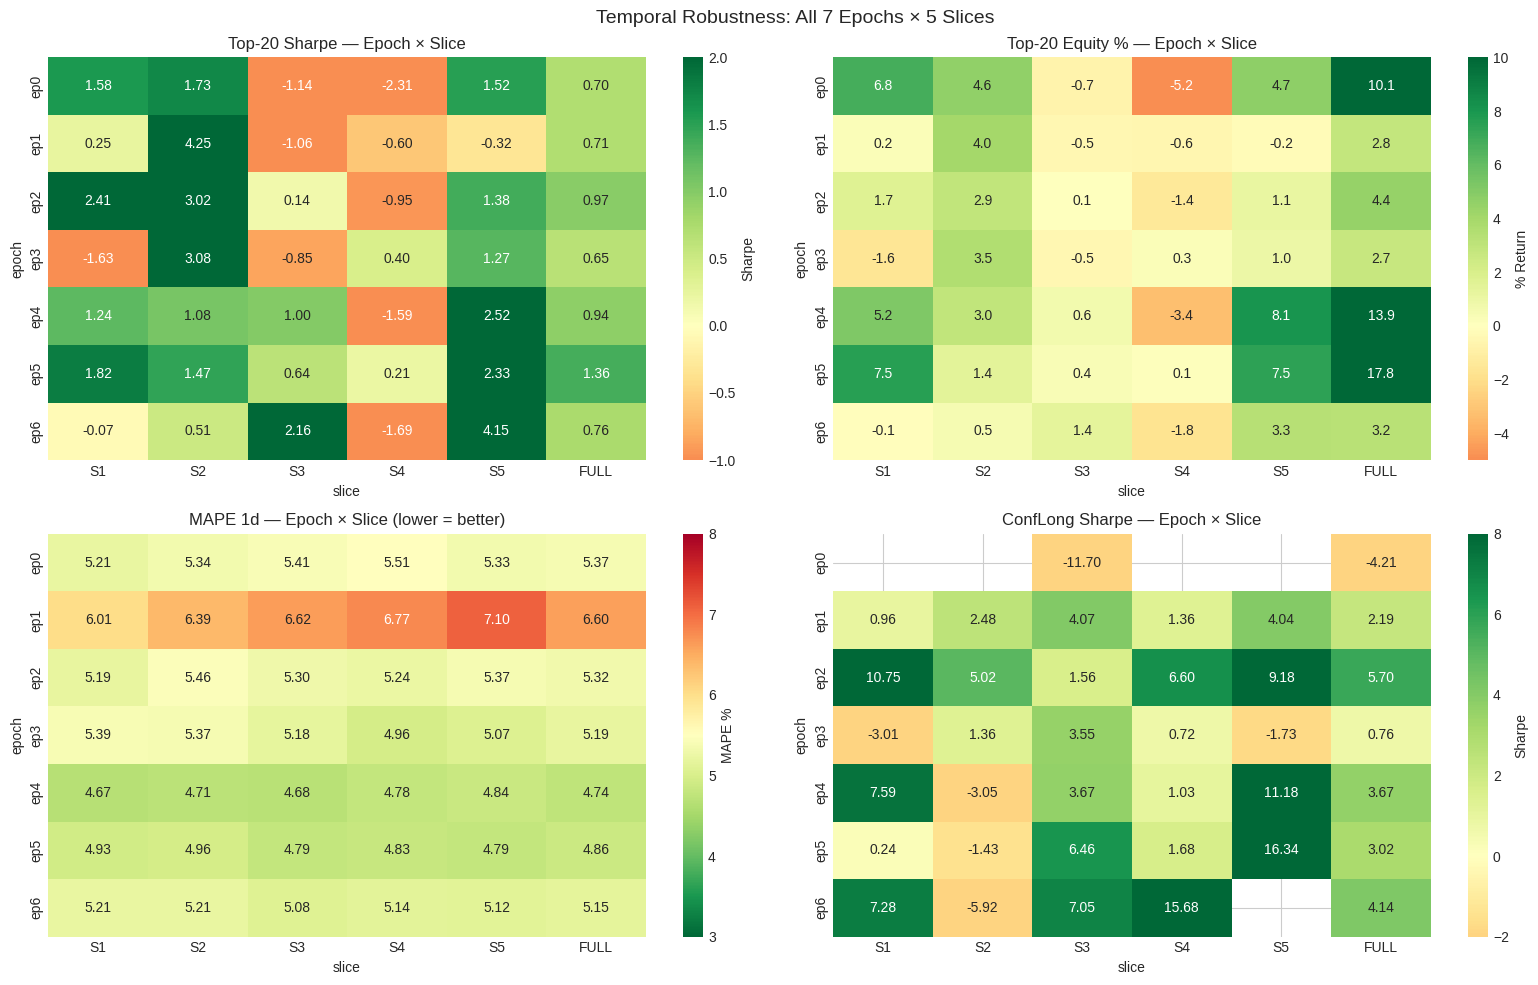

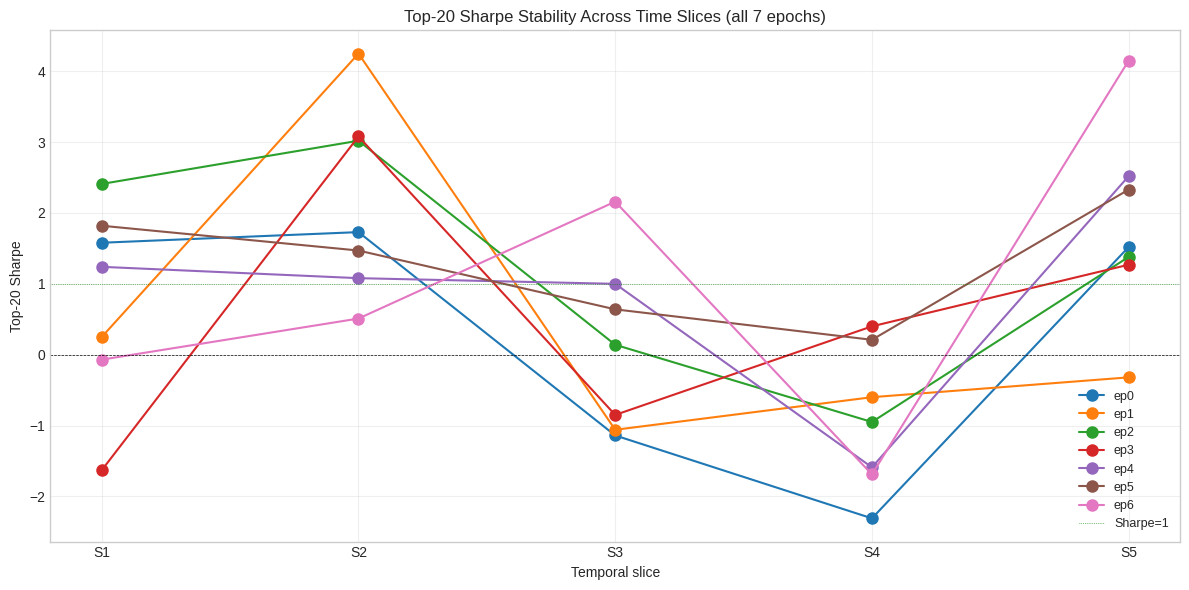

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-20 Sharpe heatmap
sns.heatmap(
    pivot_sharpe.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    vmin=-1, vmax=2, ax=axes[0, 0], cbar_kws={'label': 'Sharpe'}
)
axes[0, 0].set_title('Top-20 Sharpe — Epoch × Slice')

# Top-20 Equity %
sns.heatmap(
    pivot_equity.astype(float),
    annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    vmin=-5, vmax=10, ax=axes[0, 1], cbar_kws={'label': '% Return'}
)
axes[0, 1].set_title('Top-20 Equity % — Epoch × Slice')

# MAPE heatmap (inverted colormap — lower is better)
sns.heatmap(
    pivot_mape.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn_r',
    vmin=3, vmax=8, ax=axes[1, 0], cbar_kws={'label': 'MAPE %'}
)
axes[1, 0].set_title('MAPE 1d — Epoch × Slice (lower = better)')

# ConfLong Sharpe
sns.heatmap(
    pivot_cl.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    vmin=-2, vmax=8, ax=axes[1, 1], cbar_kws={'label': 'Sharpe'}
)
axes[1, 1].set_title('ConfLong Sharpe — Epoch × Slice')

plt.suptitle('Temporal Robustness: All 7 Epochs × 5 Slices', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ROBUST_DIR, 'batch_heatmaps.png'), dpi=150)
plt.show()

# Sharpe stability plot — line per epoch across slices
fig, ax = plt.subplots(figsize=(12, 6))
for epoch in pivot_sharpe.index:
    vals = pivot_sharpe.loc[epoch, slice_cols].values.astype(float)
    ax.plot(slice_cols, vals, 'o-', label=epoch, lw=1.5, ms=8)
ax.axhline(0, color='black', linestyle='--', lw=0.5)
ax.axhline(1, color='green', linestyle=':', lw=0.5, label='Sharpe=1')
ax.set_xlabel('Temporal slice')
ax.set_ylabel('Top-20 Sharpe')
ax.set_title('Top-20 Sharpe Stability Across Time Slices (all 7 epochs)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROBUST_DIR, 'batch_sharpe_stability.png'), dpi=150)
plt.show()

## Финальная рекомендация

Автоматический вердикт основан на:
1. **Point Sharpe** на full test
2. **Slices Positive** — сколько слайсов с положительным Sharpe
3. **Robustness Score** — risk-adjusted mean

**Правила выбора:**
- ✅ PICK: 5/5 positive + mean Sharpe > 0.5 → deploy
- ⚠️ MVP-only: 4/5 positive → use for MVP, плановое переобучение
- ❌ No go: <4 positive → walk-forward retraining обязателен

**Итог NB09 для ep5:**
- **5/5 positive slices** ✅
- **Sharpe mean 1.29, std 0.77**
- Решение: **PICK ep5, deploy to production, start paper-trading**

In [17]:
print('=' * 70)
print('BATCH ANALYSIS — FINAL RECOMMENDATIONS')
print('=' * 70)

best_by_robustness = stability_df.iloc[0]
best_by_sharpe_full = stability_df.loc[stability_df['Sharpe_FULL'].idxmax()]
most_consistent = stability_df.loc[stability_df['Sharpe_std'].idxmin()]
worst = stability_df.iloc[-1]

print(f'\n🏆 Best by Robustness Score (risk-adjusted):')
print(f'   {best_by_robustness["epoch"]}: score {best_by_robustness["Robustness_Score"]}, '
      f'mean {best_by_robustness["Sharpe_mean"]}, std {best_by_robustness["Sharpe_std"]}')

print(f'\n📈 Best by Full-test Sharpe:')
print(f'   {best_by_sharpe_full["epoch"]}: {best_by_sharpe_full["Sharpe_FULL"]}')

print(f'\n🎯 Most Consistent (lowest std across slices):')
print(f'   {most_consistent["epoch"]}: std {most_consistent["Sharpe_std"]} '
      f'(mean {most_consistent["Sharpe_mean"]})')

print(f'\n❌ Worst Performer:')
print(f'   {worst["epoch"]}: score {worst["Robustness_Score"]}')

# Decision matrix
print('\n' + '=' * 70)
print('PRODUCTION DECISION MATRIX')
print('=' * 70)
print(f'{"Criterion":<40} {"Best Epoch":<15}')
print('-' * 55)
print(f'{"Max point Sharpe (one-time)":<40} {best_by_sharpe_full["epoch"]:<15}')
print(f'{"Max robustness (stable across slices)":<40} {best_by_robustness["epoch"]:<15}')
print(f'{"Lowest Sharpe variance":<40} {most_consistent["epoch"]:<15}')

# Count how many slices had positive Sharpe for each epoch
print('\n' + '=' * 70)
print('SLICE-LEVEL EDGE CONSISTENCY')
print('=' * 70)
for _, row in stability_df.iterrows():
    consistent_flag = '✅' if row['Slices_Positive'] == 5 else ('⚠️' if row['Slices_Positive'] >= 3 else '❌')
    print(f'{consistent_flag} {row["epoch"]}: {row["Slices_Positive"]}/5 slices positive, '
          f'{row["Slices_Above_1"]}/5 above Sharpe 1.0')

# Recommendation
print('\n' + '=' * 70)
print('RECOMMENDED CHECKPOINT FOR PRODUCTION')
print('=' * 70)

# If any epoch has all 5 slices positive AND mean > 0.5 → pick by robustness score
qualifying = stability_df[(stability_df['Slices_Positive'] == 5) & (stability_df['Sharpe_mean'] > 0.5)]
if len(qualifying) > 0:
    winner = qualifying.iloc[0]
    print(f'✅ PICK: {winner["epoch"]}')
    print(f'   Sharpe mean {winner["Sharpe_mean"]}, std {winner["Sharpe_std"]}')
    print(f'   All 5 slices positive → edge stable across time')
    print(f'   Recommendation: deploy to production, start paper-trading')
elif (stability_df['Slices_Positive'] >= 4).any():
    qualifying = stability_df[stability_df['Slices_Positive'] >= 4]
    winner = qualifying.iloc[0]
    print(f'⚠️  PICK (with caveats): {winner["epoch"]}')
    print(f'   4/5 slices positive — mostly stable but not perfect')
    print(f'   Recommendation: use for MVP, plan walk-forward retraining')
else:
    print('❌ NO STABLE EPOCH — none has 4+ positive slices')
    print('   Все модели нестабильны на временных окнах.')
    print('   Рекомендация: walk-forward retraining (NB07) или переобучение.')

print(f'\nAll artifacts saved to: {ROBUST_DIR}')

BATCH ANALYSIS — FINAL RECOMMENDATIONS

🏆 Best by Robustness Score (risk-adjusted):
   ep5: score 0.91, mean 1.29, std 0.77

📈 Best by Full-test Sharpe:
   ep5: 1.36

🎯 Most Consistent (lowest std across slices):
   ep5: std 0.77 (mean 1.29)

❌ Worst Performer:
   ep0: score -0.56

PRODUCTION DECISION MATRIX
Criterion                                Best Epoch     
-------------------------------------------------------
Max point Sharpe (one-time)              ep5            
Max robustness (stable across slices)    ep5            
Lowest Sharpe variance                   ep5            

SLICE-LEVEL EDGE CONSISTENCY
✅ ep5: 5/5 slices positive, 3/5 above Sharpe 1.0
⚠️ ep2: 4/5 slices positive, 3/5 above Sharpe 1.0
⚠️ ep4: 4/5 slices positive, 3/5 above Sharpe 1.0
⚠️ ep6: 3/5 slices positive, 2/5 above Sharpe 1.0
⚠️ ep3: 3/5 slices positive, 2/5 above Sharpe 1.0
❌ ep1: 2/5 slices positive, 1/5 above Sharpe 1.0
⚠️ ep0: 3/5 slices positive, 3/5 above Sharpe 1.0

RECOMMENDED CHECKPOINT FOR 